In [54]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [55]:
df = pd.read_csv('data/load_data.csv')

In [56]:
df

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.000000,0.0,73.210000,100.00,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.000000,0.0,66.770000,100.00,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.000000,0.0,70.280000,100.00,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.000000,0.0,68.090000,100.00,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.000000,0.0,133.655666,NaN,4500.000000,Light_Load
...,...,...,...,...,...,...,...,...,...
35036,31-12-2018 23:15,3.740000,3.74,0.000000,0.0,70.710000,100.00,83700.000000,Light_Load
35037,31-12-2018 23:30,3.780000,3.17,0.070000,0.0,76.620000,99.98,157160.395291,Light_Load
35038,31-12-2018 23:45,3.780000,3.06,0.110000,0.0,187.054285,99.96,85500.000000,Light_Load
35039,31-12-2018 00:00,3.670000,3.02,0.174801,0.0,77.220000,NaN,0.000000,Light_Load


In [57]:
df.shape

(35041, 9)

In [58]:
df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


In [59]:
df.tail()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
35036,31-12-2018 23:15,3.74,3.74,0.000000,0.0,70.710000,100.00,83700.000000,Light_Load
35037,31-12-2018 23:30,3.78,3.17,0.070000,0.0,76.620000,99.98,157160.395291,Light_Load
35038,31-12-2018 23:45,3.78,3.06,0.110000,0.0,187.054285,99.96,85500.000000,Light_Load
35039,31-12-2018 00:00,3.67,3.02,0.174801,0.0,77.220000,NaN,0.000000,Light_Load
35040,31-12-2018 20:00,NaN,0.00,20.100000,0.0,217.273470,20.19,72000.000000,Light_Load


In [60]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date_Time,35041,35040,31-12-2018 20:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage_kWh,33482.0,NaN,NaN,NaN,30.873061,41.415015,0.0,3.31,5.29,53.56,435.019069
Lagging_Current_Reactive.Power_kVarh,34165.0,NaN,NaN,NaN,14.704573,20.342721,0.0,2.34,5.18,23.51,262.630718
Leading_Current_Reactive_Power_kVarh,33885.0,NaN,NaN,NaN,4.386097,9.090181,0.0,0.0,0.0,2.298558,78.809
CO2(tCO2),34586.0,NaN,NaN,NaN,0.012947,0.019726,0.0,0.0,0.0,0.02,0.188166
Lagging_Current_Power_Factor,34691.0,NaN,NaN,NaN,90.740871,39.745395,0.0,66.295,90.08,100.0,299.996814
Leading_Current_Power_Factor,33570.0,NaN,NaN,NaN,94.926552,49.826872,0.0,99.8,100.0,100.0,299.969494
NSM,34586.0,NaN,NaN,NaN,48013.664032,34046.492333,0.0,22500.0,45000.0,68400.0,248821.810465
Load_Type,35041,3,Light_Load,18073,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
df['Load_Type'].value_counts(normalize=False)


Load_Type
Light_Load      18073
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

In [62]:
df.isnull().sum().sort_values(ascending=False)

Usage_kWh                               1559
Leading_Current_Power_Factor            1471
Leading_Current_Reactive_Power_kVarh    1156
Lagging_Current_Reactive.Power_kVarh     876
CO2(tCO2)                                455
NSM                                      455
Lagging_Current_Power_Factor             350
Date_Time                                  0
Load_Type                                  0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date_Time'])

In [65]:
df.columns = df.columns.str.replace('.', '_', regex=False)
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '')
df.columns = df.columns.str.replace(')', '')

In [66]:
df = df.drop_duplicates()

In [67]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.head()

,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2tCO2,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,year,Month,day,weekday,hour,is_weekend,Date_Time
0,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,0,2018,1,1,0,0,0,2018-01-01 00:15:00
1,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,0,2018,1,1,0,0,0,2018-01-01 00:30:00
2,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,0,2018,1,1,0,2,0,2018-01-01 00:45:00
3,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,0,2018,1,1,0,1,0,2018-01-01 01:00:00
4,3.820000,4.50,0.0,0.0,133.655666,100.0,4500.000000,0,2018,1,1,0,1,0,2018-01-01 01:15:00


__1__

In [68]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [69]:
df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2tCO2,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,2018-01-01 00:15:00,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,2018-01-01 00:30:00,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,2018-01-01 00:45:00,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,2018-01-01 01:00:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,2018-01-01 01:15:00,3.820000,4.50,0.0,0.0,133.655666,100.0,4500.000000,Light_Load


__2__

In [84]:
df["year"] = df["Date_Time"].dt.year
df["Month"] = df["Date_Time"].dt.month
df["day"] = df["Date_Time"].dt.day
df['weekday'] = df['Date_Time'].dt.weekday
df['hour'] = (df['NSM'] // 3600).astype(int)
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [85]:
df.head()

,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2tCO2,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,year,Month,day,weekday,hour,is_weekend,Date_Time
0,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,0,2018,1,1,0,0,0,2018-01-01 00:15:00
1,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,0,2018,1,1,0,0,0,2018-01-01 00:30:00
2,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,0,2018,1,1,0,2,0,2018-01-01 00:45:00
3,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,0,2018,1,1,0,1,0,2018-01-01 01:00:00
4,3.820000,4.50,0.0,0.0,133.655666,100.0,4500.000000,0,2018,1,1,0,1,0,2018-01-01 01:15:00


In [71]:
df = df.drop(columns=['Date_Time'])

__3__

In [72]:
le = LabelEncoder()
df['Load_Type'] = le.fit_transform(df['Load_Type'])

print("Class Mapping:")
for i, class_name in enumerate(le.classes_):
    print(class_name, "=", i)

Class Mapping:
Light_Load = 0
Maximum_Load = 1
Medium_Load = 2


__4__

In [ ]:
df_full = pd.read_csv("data/load_data.csv")
df_full['Date_Time'] = pd.to_datetime(df_full['Date_Time'], dayfirst=True)

last_date = df_full['Date_Time'].max()
test_start = last_date.replace(day=1)

df['Date_Time'] = df_full['Date_Time']

train = df[df['Date_Time'] < test_start]
test = df[df['Date_Time'] >= test_start]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (32159, 15)
Test shape: (2882, 15)


In [74]:
X_train = train.drop(columns=['Load_Type', 'Date_Time'])
y_train = train['Load_Type']

X_test = test.drop(columns=['Load_Type', 'Date_Time'])
y_test = test['Load_Type']

__4__

In [75]:
rf = RandomForestClassifier( n_estimators=200, max_depth=None,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [76]:
y_pred = rf.predict(X_test)

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8907009021512838


In [78]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

  Light_Load       0.99      0.90      0.94      1706
Maximum_Load       0.84      0.78      0.81       504
 Medium_Load       0.74      0.95      0.83       672

    accuracy                           0.89      2882
   macro avg       0.86      0.87      0.86      2882
weighted avg       0.90      0.89      0.89      2882



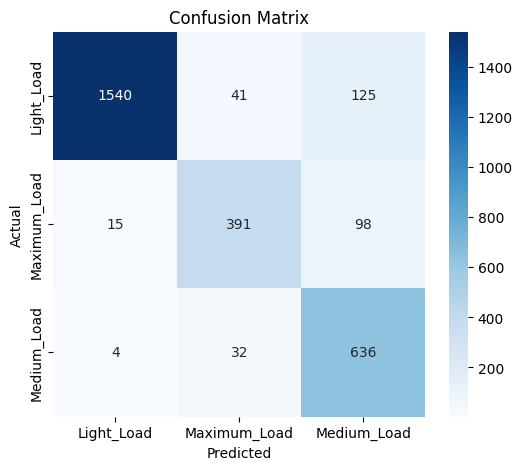

In [79]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=20, cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}


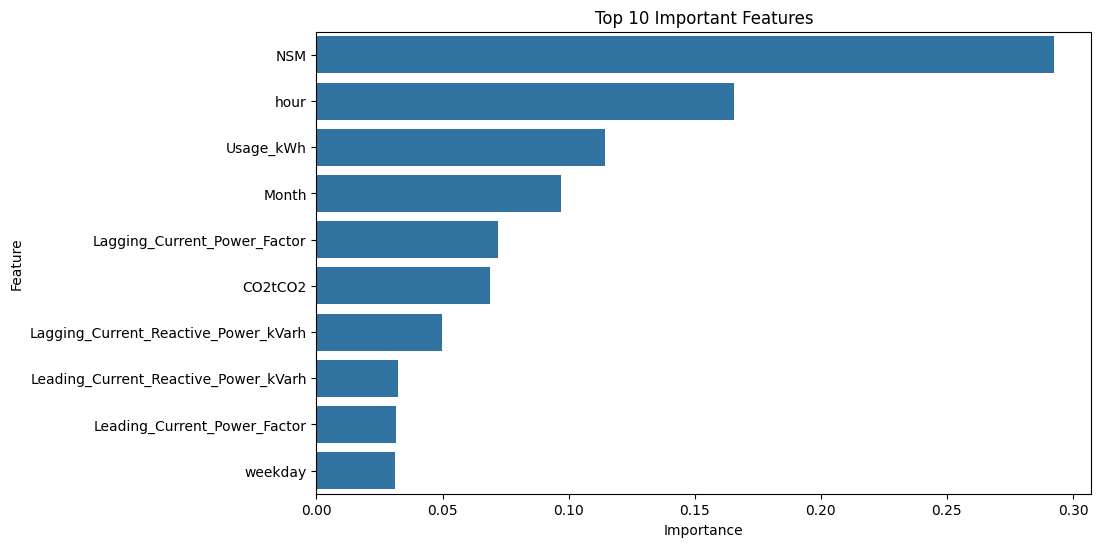

In [81]:
importances = rf.feature_importances_
features = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [82]:
joblib.dump(rf,"rf_load_model.joblib")
joblib.dump(le, "label_encoder.joblib")

['label_encoder.joblib']